# Cosine Similarity With Random Graphs

## 📦 **Package Import**

In [1]:
# python
import pandas as pd
import numpy as np
from IPython.display import display, Markdown
import sys
import os
from pathlib import Path
import re

# PepProtGraphAnalyzer framework
sys.path.append('/home/jovyan/work/PepProtGraphAnalyzer')
from PepProtGraphAnalyzer.module.notebook import NotebookApp
from PepProtGraphAnalyzer.util.plotting import boxplot, scatter

app = NotebookApp('.env.jupyter.StarPep')
paths = app.paths()

[2025-09-23 19:19:52,983] WARNING [data_validator.py:87] Sequences with non-natural amino acids were excluded. See: /home/jovyan/work/output/out_paper/Starpep/Log/Sequences with Non-Natural Amino Acids.csv
[2025-09-23 19:20:01,370] INFO [notebook.py:70] Setting:
dataset_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/StarPep.csv
pdb_path: /home/jovyan/work/PepProtGraphAnalyzer/dataset/StarPep/ESMFold_pdbs
notebook_output_path: /home/jovyan/work/output/out_paper/Starpep
sequence_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.42.20-Sequence_Analyzer
graph_analysis_path: /home/jovyan/work/PepProtGraphAnalyzer/output/results_with_seq_10_to_100/StarPep/2025-04-07T19.56.31-Graph_Analyzer
min_seq_len: 10
max_seq_len: 100


## 📊 **Data Analysis**

### **Data**

In [2]:
data = pd.read_csv(app.graph_analysis['similarity_with_random_graphs'])

data["distance_interval"] = data["distance_function"] + " " + data["interval"].astype(str)

statistics = pd.read_csv(
    app.graph_analysis['similarity_with_random_graphs_summary'].with_name(
        app.graph_analysis['similarity_with_random_graphs_summary'].name + "-cosine_similarity.csv"
    )
)

statistics["distance_interval"] = statistics["distance_function"] + " " + statistics["interval"].astype(str)

data[["sequence", "distance_interval", "cosine_similarity"]].head()

,sequence,distance_interval,cosine_similarity
0,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836)",0.512457
1,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836)",0.819630
2,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836)",0.649497
3,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836)",0.289345
4,GIGAVLKVLTTGLPALISWIKRKRQQ,"euclidean (0, 10.2836)",0.178986


### **Distance Intervals**

In [3]:
unique_values = pd.Series(pd.concat([statistics["distance_interval"], statistics["distance_interval"]]).unique()).sort_values()
display(Markdown("\n".join(f"- {val}" for val in unique_values)))

- angular_separation (0, 0.018)
- angular_separation (0, 0.0654)
- angular_separation (0, 0.1799)
- bhattacharyya (0, 1.5158)
- bhattacharyya (0, 2.4304)
- bhattacharyya (0, 3.6452)
- canberra (0, 0.6155)
- canberra (0, 1.0142)
- canberra (0, 1.4712)
- clark (0, 0.4161)
- clark (0, 0.6813)
- clark (0, 0.983)
- euclidean (0, 10.2836)
- euclidean (0, 16.6132)
- euclidean (0, 26.242)
- lance_williams (0, 0.1789)
- lance_williams (0, 0.3041)
- lance_williams (0, 0.466)
- soergel (0, 0.3035)
- soergel (0, 0.4664)
- soergel (0, 0.6357)

### **Number of Random Graphs per Distance Interval**

In [4]:
first_sequence = data["sequence"].iloc[0]
df_filtered = data[data["sequence"] == first_sequence]
count = df_filtered.groupby(["distance_function", "interval"])["random_graph"].count()
display(Markdown("\n".join(f"- {idx[0]}, {idx[1]}: {val}" for idx, val in count.items())))

- angular_separation, (0, 0.018): 30
- angular_separation, (0, 0.0654): 30
- angular_separation, (0, 0.1799): 30
- bhattacharyya, (0, 1.5158): 30
- bhattacharyya, (0, 2.4304): 30
- bhattacharyya, (0, 3.6452): 30
- canberra, (0, 0.6155): 30
- canberra, (0, 1.0142): 30
- canberra, (0, 1.4712): 30
- clark, (0, 0.4161): 30
- clark, (0, 0.6813): 30
- clark, (0, 0.983): 30
- euclidean, (0, 10.2836): 30
- euclidean, (0, 16.6132): 30
- euclidean, (0, 26.242): 30
- lance_williams, (0, 0.1789): 30
- lance_williams, (0, 0.3041): 30
- lance_williams, (0, 0.466): 30
- soergel, (0, 0.3035): 30
- soergel, (0, 0.4664): 30
- soergel, (0, 0.6357): 30

### **Statistics**

In [5]:
columns = ["distance_interval", "count", "min", "mean", "std", "p25", "p50", "p75", "max", "skewness", "kurtosis"]
display(statistics.reset_index(drop=True)[columns])

,distance_interval,count,min,mean,std,p25,p50,p75,max,skewness,kurtosis
0,"angular_separation (0, 0.018)",1038150,-0.964838,0.461123,0.277349,0.341228,0.510939,0.650380,0.994709,-1.434074,5.958840
1,"angular_separation (0, 0.0654)",1039080,-0.932514,0.585002,0.216589,0.508603,0.633831,0.718572,0.997600,-2.185525,10.012780
2,"angular_separation (0, 0.1799)",1039080,-0.884931,0.647751,0.194370,0.614505,0.691420,0.742936,0.993686,-3.415503,17.891936
3,"bhattacharyya (0, 1.5158)",1039080,-0.909478,0.516517,0.181446,0.401123,0.510338,0.635363,0.996419,-0.336822,4.319853
4,"bhattacharyya (0, 2.4304)",1039080,-0.590142,0.623547,0.132107,0.530658,0.618926,0.717332,0.996655,0.001541,2.838954
5,"bhattacharyya (0, 3.6452)",1039080,-0.608995,0.681842,0.112388,0.621777,0.686692,0.750229,0.978917,-2.960088,30.238514
6,"canberra (0, 0.6155)",1037880,-0.975210,0.507516,0.247528,0.426849,0.540001,0.648205,0.997748,-2.214878,10.762208
7,"canberra (0, 1.0142)",1039080,-0.926953,0.630324,0.133633,0.551872,0.634401,0.716679,0.996039,-1.205008,11.222635
8,"canberra (0, 1.4712)",1039080,-0.770277,0.678534,0.101710,0.618895,0.681410,0.742669,0.998840,-1.158635,13.410834
9,"clark (0, 0.4161)",1038300,-0.964963,0.512770,0.244384,0.434321,0.546150,0.652695,0.994293,-2.164666,10.426581


### **Analysis of Graph Similarity Distribution (*per Percentile*)**

#### **25th Percentile**

<br>*Cosine Similarity with Random Graphs (25th Percentile)*

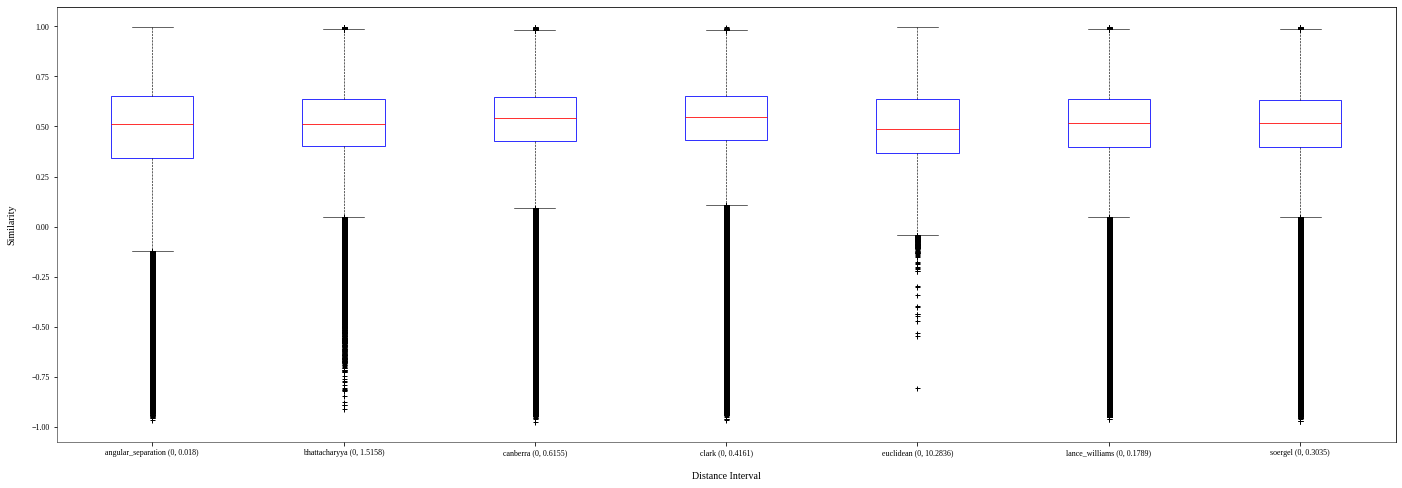

<br>*Cosine Similarity with Random Graphs (25th Percentile)*

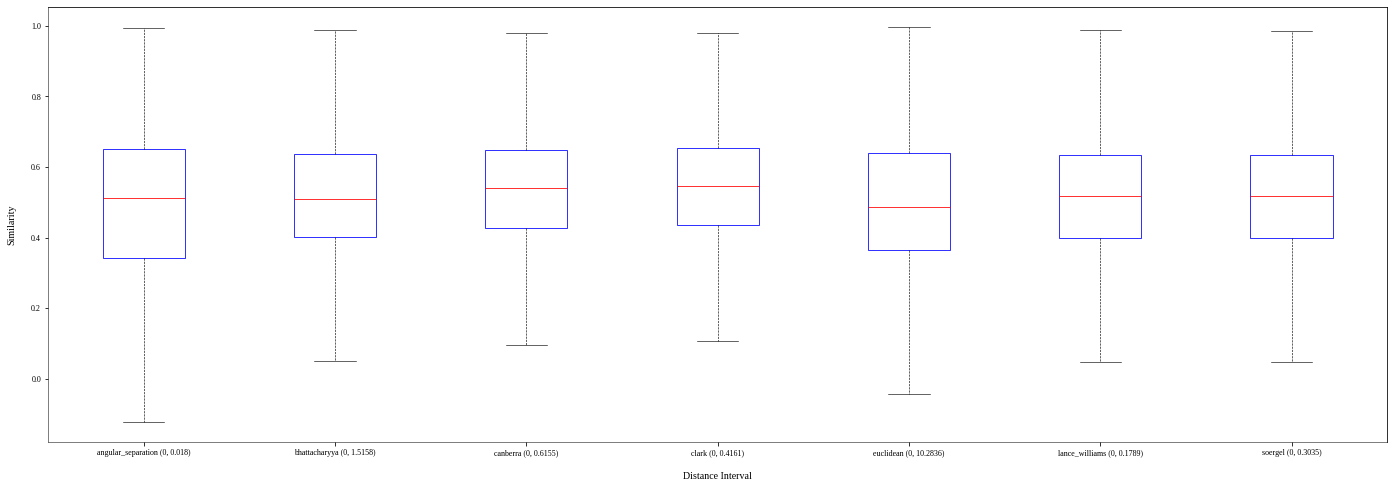

In [6]:
distance_intervals = [
    'euclidean (0, 10.2836)',
    'angular_separation (0, 0.018)',
    'bhattacharyya (0, 1.5158)',
    'canberra (0, 0.6155)',
    'clark (0, 0.4161)',
    'lance_williams (0, 0.1789)',
    'soergel (0, 0.3035)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (25th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p25_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **50th Percentile**

<br>*Cosine Similarity with Random Graphs (50th Percentile)*

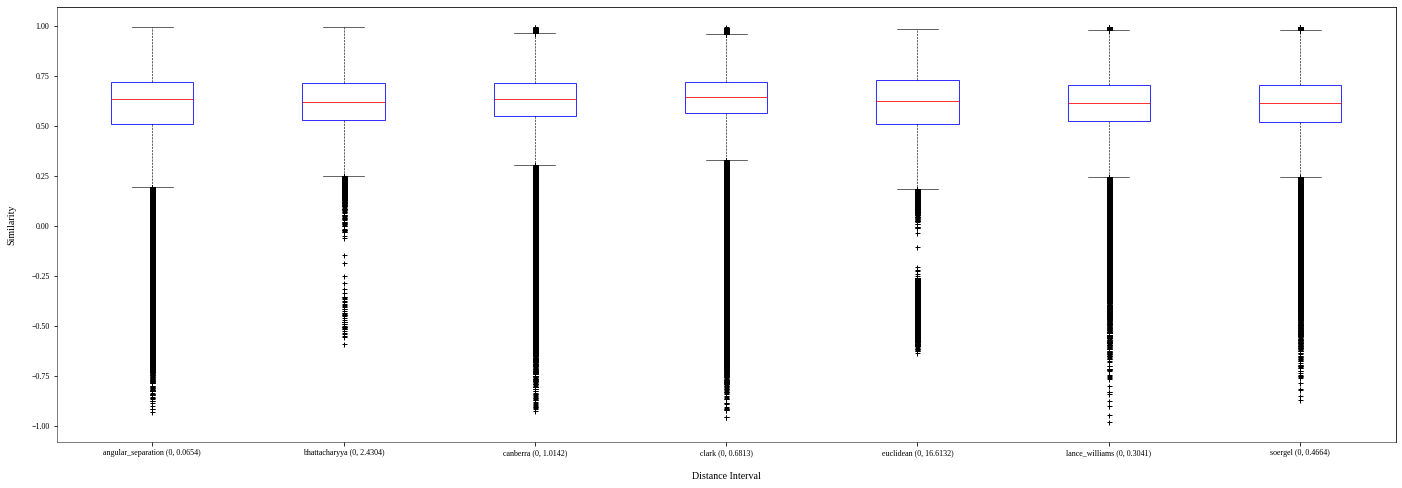

<br>*Cosine Similarity with Random Graphs (20th Percentile)*

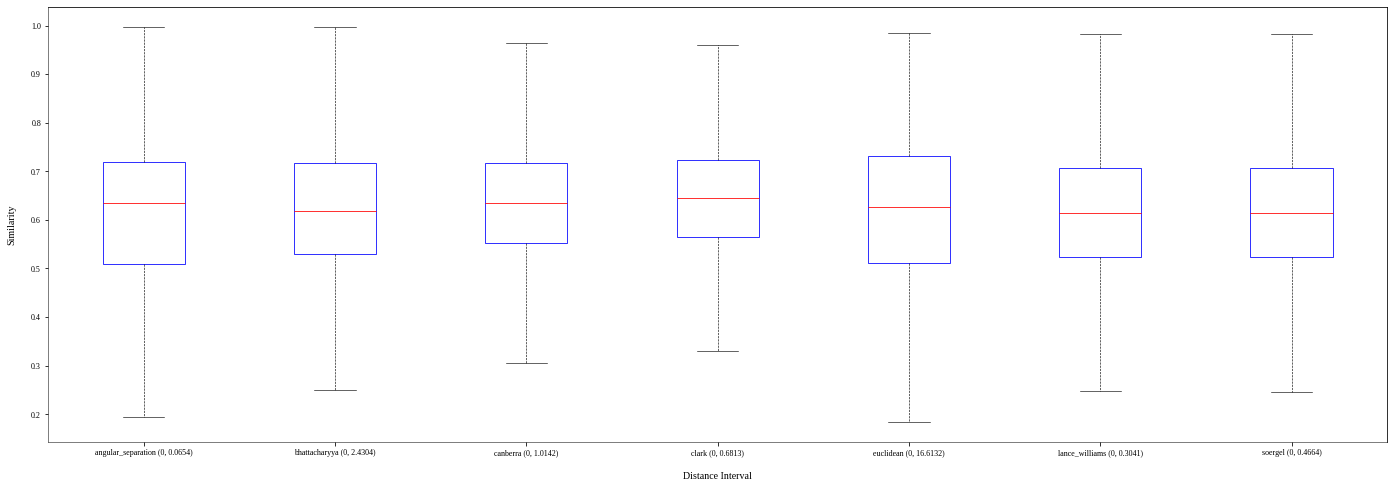

In [7]:
distance_intervals = [
    'euclidean (0, 16.6132)',
    'angular_separation (0, 0.0654)',
    'bhattacharyya (0, 2.4304)',
    'canberra (0, 1.0142)',
    'clark (0, 0.6813)',
    'lance_williams (0, 0.3041)',
    'soergel (0, 0.4664)'  
]

regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (50th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (20th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p50_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False)
plt.show()

#### **75th Percentile**

<br>*Cosine Similarity with Random Graphs (75th Percentile)*

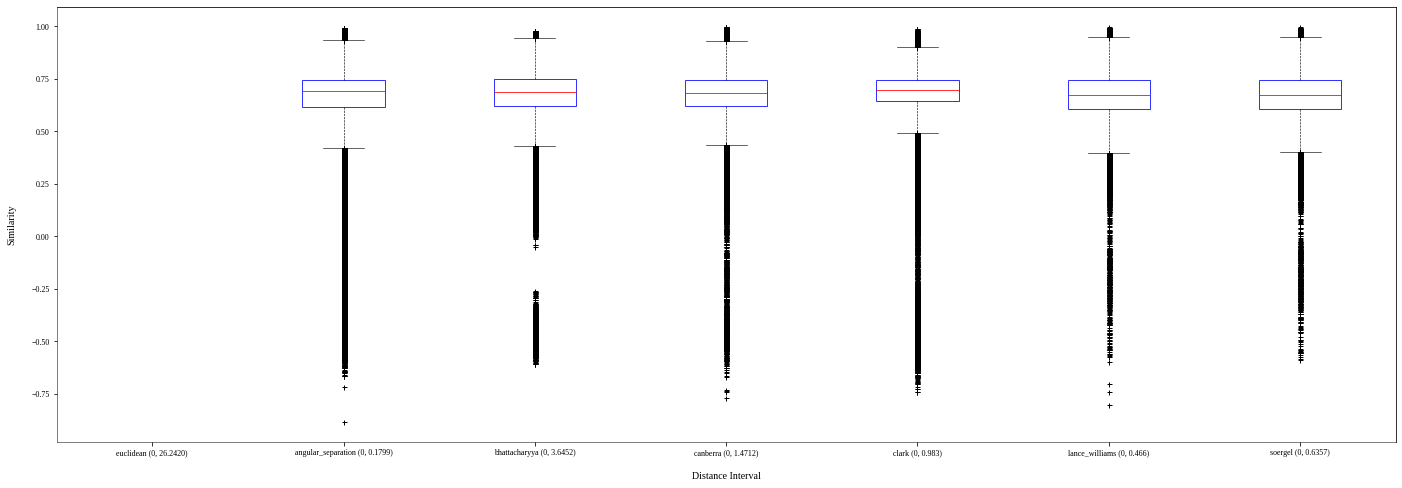

<br>*Cosine Similarity with Random Graphs (75th Percentile)*

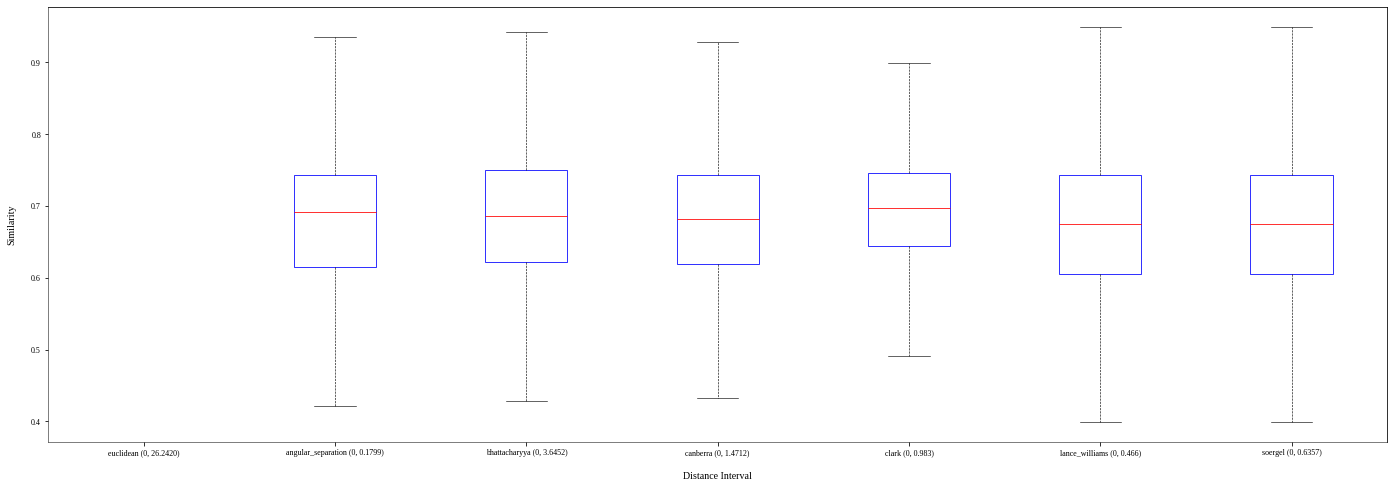

In [8]:
distance_intervals = [
    'euclidean (0, 26.2420)',
    'angular_separation (0, 0.1799)',
    'bhattacharyya (0, 3.6452)',
    'canberra (0, 1.4712)',
    'clark (0, 0.983)',
    'lance_williams (0, 0.466)',
    'soergel (0, 0.6357)'  
]


regex_pattern = '|'.join([re.escape(interval) for interval in distance_intervals])

data_rg = data.dropna(subset=['cosine_similarity']).copy()
data_rg = data_rg[data_rg['distance_interval'].astype(str).str.contains(regex_pattern, na=False)]

x_axis = 'distance_interval'
y_axis = 'cosine_similarity'
x_label = 'Distance Interval'
y_label = 'Similarity'
fig_size=(24, 8)
x_tick_rotation=0
y_lim=None

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, categories=distance_intervals)
plt.show()

display(Markdown("<br>*Cosine Similarity with Random Graphs (75th Percentile)*"))
output = paths['random_graphs_path'].joinpath("Cosine Similarity with Random Graphs (p75_distance_intervals) -boxplot_without_outliter")
plt = boxplot(data_rg, x_axis, y_axis, x_label, y_label, y_lim=y_lim, output=output, fig_size=fig_size, x_tick_rotation=x_tick_rotation, show_fliers=False, categories=distance_intervals)
plt.show()